In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('telco_comm_churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Basic Info

In [3]:
df.shape

(7043, 21)

In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
print("Missing Value")
df.isnull().sum()

Missing Value


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
print("Target Value Distribution")
df['Churn'].value_counts()

Target Value Distribution


Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [7]:
print("Target Value Distribution")
print(f" Churn Rate Yes:{df['Churn'].value_counts(normalize = True)['Yes'] * 100: .2f}%")
print(f" Churn Rate No:{df['Churn'].value_counts(normalize = True)['No'] * 100: .2f}%")

Target Value Distribution
 Churn Rate Yes: 26.54%
 Churn Rate No: 73.46%


## Analyse Numerical Feature

In [29]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols

['SeniorCitizen', 'tenure', 'MonthlyCharges']

In [32]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')

In [33]:
df[numerical_cols].describe().round(2)

,SeniorCitizen,tenure,MonthlyCharges
count,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76
std,0.37,24.56,30.09
min,0.00,0.00,18.25
25%,0.00,9.00,35.50
50%,0.00,29.00,70.35
75%,0.00,55.00,89.85
max,1.00,72.00,118.75


### Visualize Target Varaible

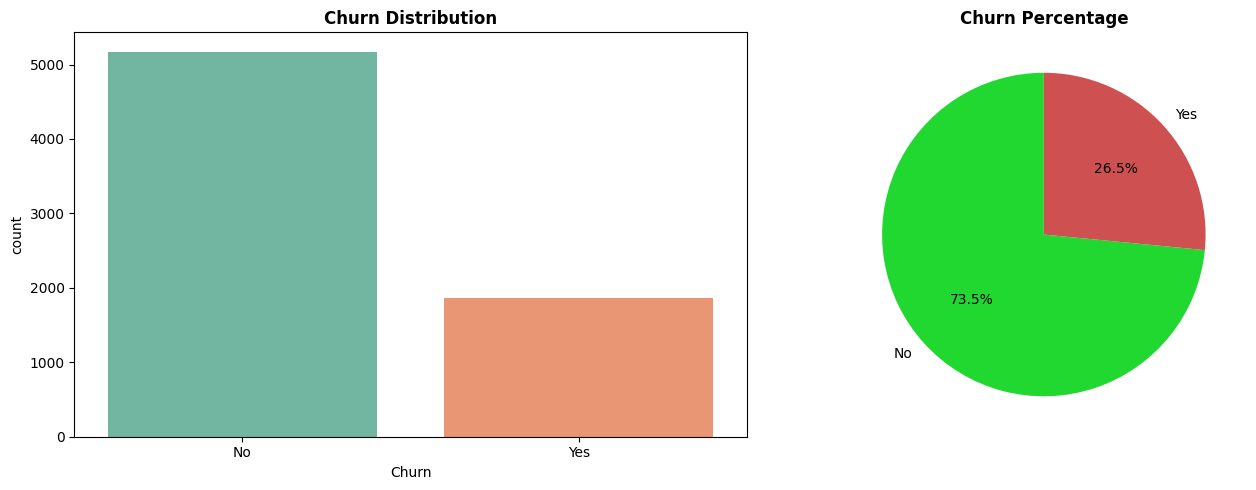

saved : figure_reports/churn_distribution


In [34]:
fig,ax = plt.subplots(1,2, figsize=(14,5))
sns.countplot(data = df,
             x = 'Churn',
             ax=ax[0],
             palette='Set2')
ax[0].set_title('Churn Distribution',fontweight='bold')

churn_count = df['Churn'].value_counts()
ax[1].pie(churn_count,
         labels=churn_count.index,
         autopct = '%1.1f%%',
         startangle = 90,
         colors=["#21d830","#ce5050"])
ax[1].set_title('Churn Percentage',fontweight='bold')


plt.tight_layout()
# save fig
plt.savefig('../figure_reports/churn_distribution.png',dpi=80,bbox_inches='tight')
plt.show()

print(f"saved : figure_reports/churn_distribution")

### Numerical Fatures v/s Churn

<Axes: xlabel='Churn', ylabel='TotalCharges'>

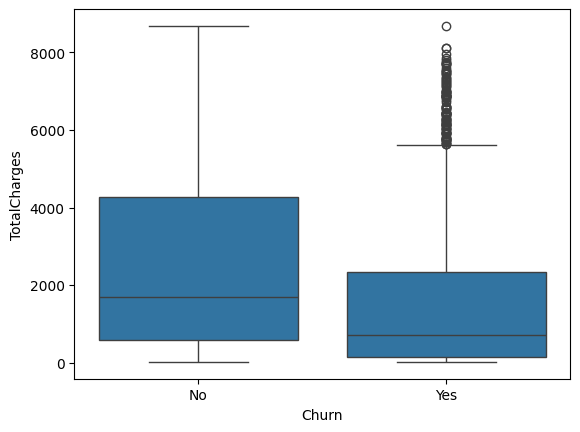

In [35]:
sns.boxplot(data=df,x='Churn',y='TotalCharges')

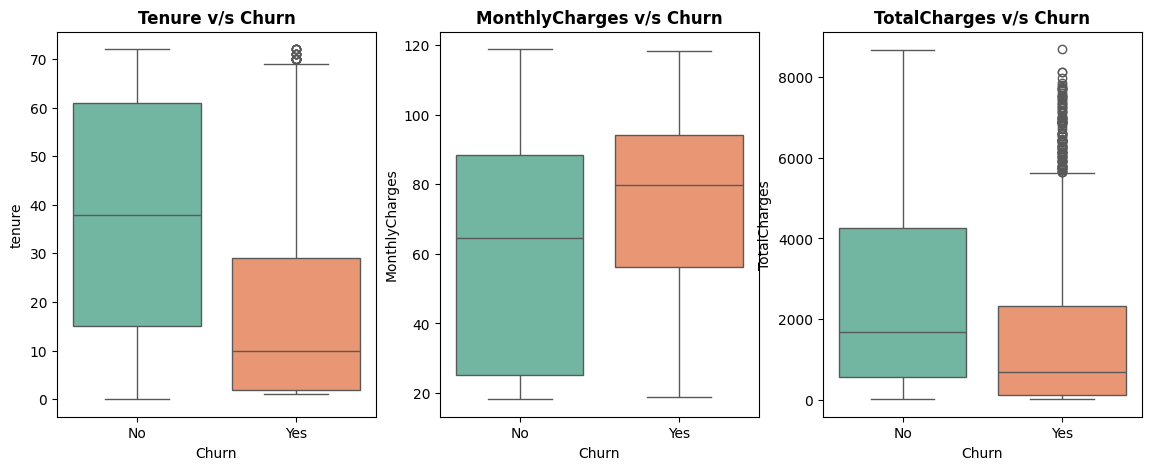

In [38]:
fig,ax = plt.subplots(1,3,figsize=(14,5))

#TODO: First Graph- Tenure
sns.boxplot(data=df,x='Churn',y='tenure',ax=ax[0],palette='Set2')
ax[0].set_title('Tenure v/s Churn',fontweight='bold')

#TODO: Second Graph- MonthlyCharges
sns.boxplot(data=df,x='Churn',y='MonthlyCharges',ax=ax[1],palette='Set2')
ax[1].set_title('MonthlyCharges v/s Churn',fontweight='bold')

#TODO: Third Graph- TotalCharges
sns.boxplot(data=df,x='Churn',y='TotalCharges',ax=ax[2],palette='Set2')
ax[2].set_title('TotalCharges v/s Churn',fontweight='bold')

plt.savefig('../figure_reports/numerical_analysis.png',dpi=80,bbox_inches='tight')
plt.show()


### Analyse Categorical Features

In [49]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols

['customerID',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [50]:
categorical_cols.remove("customerID")
categorical_cols.remove("Churn")
categorical_cols                

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [51]:
print(F"categorical_cols ({len(categorical_cols)}):{categorical_cols}")

categorical_cols (15):['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


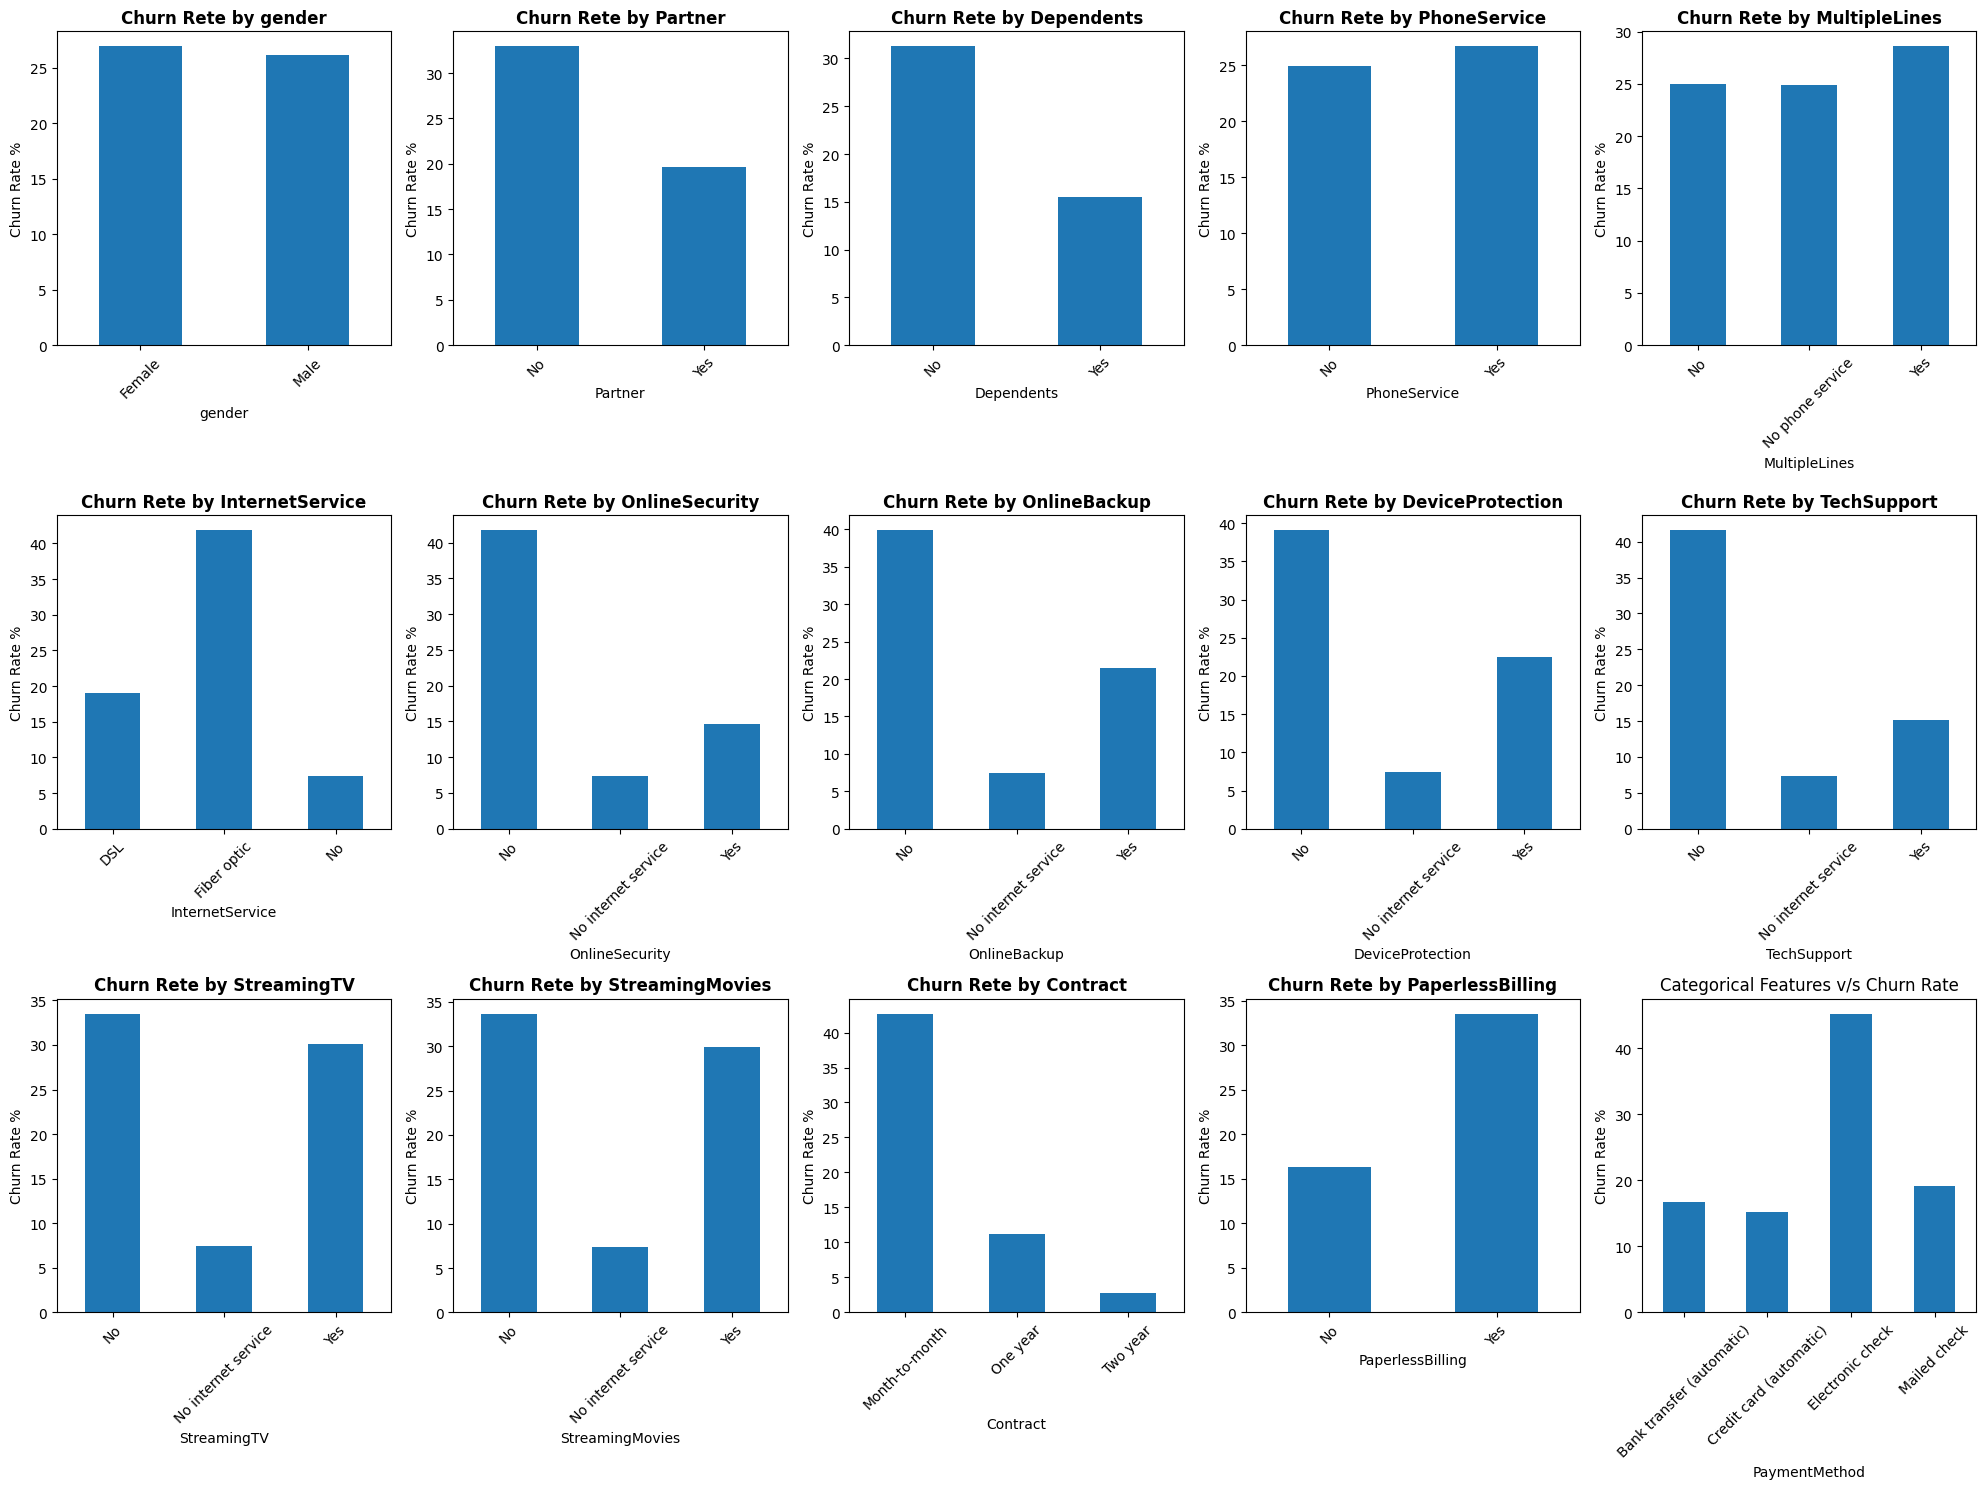

In [69]:
fig,ax = plt.subplots(3,5, figsize=(20,15))
ax = ax.flatten()

for idx,col in enumerate(categorical_cols):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x:(x=='Yes').sum()/len(x)*100)
    churn_rate.plot(kind='bar',ax =ax[idx])
    ax[idx].set_title(f'Churn Rete by {col}',fontweight='bold')
    ax[idx].set_ylabel('Churn Rate %')
    ax[idx].set_xlabel(col)
    ax[idx].tick_params(axis='x',rotation=45)

plt.title('Categorical Features v/s Churn Rate')
plt.tight_layout()
plt.savefig('../figure_reports/categorical_analysis.png',dpi=80,bbox_inches='tight')
plt.show()

In [74]:
df_corr=df.copy()
df_corr['Churn'] = df_corr['Churn'].map({'Yes':1, 'No':0})

In [75]:
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges','Churn']
corr_matrix = df_corr[numerical_features].corr()
corr_matrix

,tenure,MonthlyCharges,TotalCharges,Churn
tenure,1.000000,0.247900,0.825880,-0.352229
MonthlyCharges,0.247900,1.000000,0.651065,0.193356
TotalCharges,0.825880,0.651065,1.000000,-0.199484
Churn,-0.352229,0.193356,-0.199484,1.000000


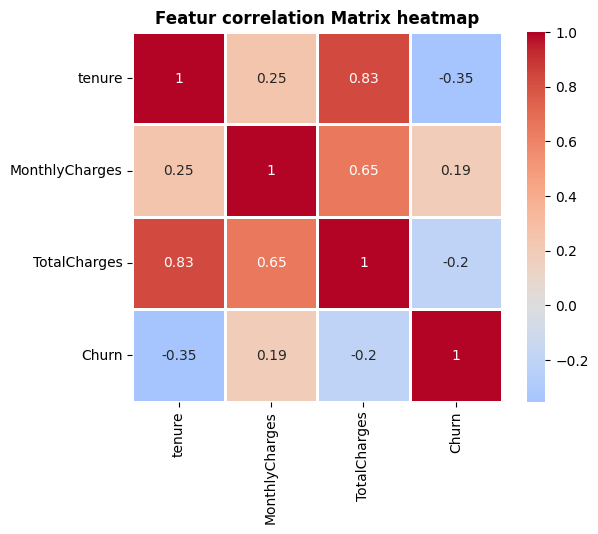

In [78]:
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',center=0,square=True, linewidths=1)
plt.title("Featur correlation Matrix heatmap", fontweight='bold')
plt.savefig('../figure_reports/correlation Matrix heatmap.png',dpi=80,bbox_inches='tight')
plt.show()

## NOTES

In [80]:
print("="*60)
print("KEY INSIGHTS FROM EDA")
print("="*60)

print(f"\n1. Dataset size: {df.shape[0]} customers, {df.shape[1]} features")
print(f"2. Churn rate: {(df['Churn']=='Yes').sum()/len(df)*100:.2f}%")
print(f"3. Missing Values: {df.isnull().sum().sum()} total")

avg_tenure_churn = df[df['Churn'] == 'Yes']['tenure'].mean()
avg_tenure_no_churn = df[df['Churn'] == 'No']['tenure'].mean()

print(f"4. Average Tenure (Churned): {avg_tenure_churn:.1f} months")
print(f"5. Average Tenure (Not Churned): {avg_tenure_no_churn:.1f} months")

avg_monthly_churn = df[df['Churn'] == 'Yes']['MonthlyCharges'].mean()
avg_monthly_no_churn = df[df['Churn'] == 'No']['MonthlyCharges'].mean()
print(f"6. Average Monthly Chrages (Churned): ${avg_monthly_churn:.1f}")
print(f"7. Average Monthly (Not Churned): ${avg_monthly_no_churn:.1f}\n")

print("="*60)
print('A holistic analysis reveals that short-term, high-cost digital\n services (Fiber Optic/Electronic Checks) are the primary churn\n drivers, while long-term tenure and value-added security\n services are the strongest indicators of customer loyalty.')
print("="*60)

print("="*60)
print("EDA COMPLETED")
print("="*60)

KEY INSIGHTS FROM EDA

1. Dataset size: 7043 customers, 21 features
2. Churn rate: 26.54%
3. Missing Values: 11 total
4. Average Tenure (Churned): 18.0 months
5. Average Tenure (Not Churned): 37.6 months
6. Average Monthly Chrages (Churned): $74.4
7. Average Monthly (Not Churned): $61.3

A holistic analysis reveals that short-term, high-cost digital
 services (Fiber Optic/Electronic Checks) are the primary churn
 drivers, while long-term tenure and value-added security
 services are the strongest indicators of customer loyalty.
EDA COMPLETED
